IMPORTING LIBRARIES

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

IMPORTING DATASET

In [63]:
dataset_training = pd.read_csv('Google_Stock_Price_Train.csv')
training_set = dataset_training.iloc[:, 1:2].values

print(training_set)

[[325.25]
 [331.27]
 [329.83]
 ...
 [793.7 ]
 [783.33]
 [782.75]]


APPLYING THE FEATURE SCALING

In [64]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = sc.fit_transform(training_set)

print(training_set_scaled)

[[0.08581368]
 [0.09701243]
 [0.09433366]
 ...
 [0.95725128]
 [0.93796041]
 [0.93688146]]


CREATING THE DATA STRUCTURE OF 60 TIMESTAMPS AND 1 OUTPUT

In [65]:
x_train = []
y_train = []

for i in range(60,len(training_set_scaled)):
  x_train.append(training_set_scaled[i-60:i, 0])
  y_train.append(training_set_scaled[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)


print(x_train)
print(y_train)

[[0.08581368 0.09701243 0.09433366 ... 0.07846566 0.08034452 0.08497656]
 [0.09701243 0.09433366 0.09156187 ... 0.08034452 0.08497656 0.08627874]
 [0.09433366 0.09156187 0.07984225 ... 0.08497656 0.08627874 0.08471612]
 ...
 [0.92106928 0.92438053 0.93048218 ... 0.95475854 0.95204256 0.95163331]
 [0.92438053 0.93048218 0.9299055  ... 0.95204256 0.95163331 0.95725128]
 [0.93048218 0.9299055  0.93113327 ... 0.95163331 0.95725128 0.93796041]]
[0.08627874 0.08471612 0.07454052 ... 0.95725128 0.93796041 0.93688146]


RESHAPING

In [66]:
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print(x_train)

[[[0.08581368]
  [0.09701243]
  [0.09433366]
  ...
  [0.07846566]
  [0.08034452]
  [0.08497656]]

 [[0.09701243]
  [0.09433366]
  [0.09156187]
  ...
  [0.08034452]
  [0.08497656]
  [0.08627874]]

 [[0.09433366]
  [0.09156187]
  [0.07984225]
  ...
  [0.08497656]
  [0.08627874]
  [0.08471612]]

 ...

 [[0.92106928]
  [0.92438053]
  [0.93048218]
  ...
  [0.95475854]
  [0.95204256]
  [0.95163331]]

 [[0.92438053]
  [0.93048218]
  [0.9299055 ]
  ...
  [0.95204256]
  [0.95163331]
  [0.95725128]]

 [[0.93048218]
  [0.9299055 ]
  [0.93113327]
  ...
  [0.95163331]
  [0.95725128]
  [0.93796041]]]


BUILDING THE RECURRENT NEURAL NETWORK (RNN)

IMPORTING KERAS LIBRARIES

In [67]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout

INITIALIZING THE RNN

In [68]:
regressor = Sequential()

ADDING THE FIRST LSTM LAYER AND SOME DROPOUT REGULARISATION

In [69]:
regressor.add(LSTM(units = 50, return_sequences = True, input_shape = (x_train.shape[1], 1)))
regressor.add(Dropout(0.2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ADDING THE SECOND LSTM LAYER AND SOME DROPOUT REGULARISATION

In [70]:
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

ADDING THE THIRD LSTM LAYER AND SOME DROPOUT REGULARISATION

In [71]:
regressor.add(LSTM(units = 50, return_sequences = True))
regressor.add(Dropout(0.2))

ADDING THE FOURTH LSTM LAYER AND SOME DROPOUT REGULARISATION

In [72]:
regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.2))

ADDING THE OUTPUT LAYER

In [73]:
regressor.add(Dense(units = 1))

COMPILING THE RNN

In [74]:
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error')

FITTING THE RNN TO TRAINING SET

In [58]:
regressor.fit(x_train, y_train, epochs = 100, batch_size = 32)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - loss: 0.1002
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - loss: 0.0078
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - loss: 0.0073
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 149ms/step - loss: 0.0057
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - loss: 0.0063
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 136ms/step - loss: 0.0050
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0051
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - loss: 0.0051
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - loss: 0.0056
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - loss: 0.0049
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - loss: 0.0043
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 140ms/step - loss: 0.0042
Epoch 13/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - loss: 0.0043
Epoch 14/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0046
Epoch 15/100
38/38 ━━━━━━━━━━━━━━━━━━━━

MAKING THE PREDICTION AND VISUALISING TEH RESULTS

GETTING TEH REAL STOCK PRICES OF 2017

In [59]:
dataset_test = pd.read_csv('Google_Stock_Price_Test.csv')
training_set = dataset_test.iloc[:, 1:2].values

GETTIG THE PREDICTIED STOCK PRICE OF 2017

In [60]:
dataset_total = pd.concat((dataset_training['Open'], dataset_test['Open']), axis = 0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

x_test = []

for i in range(60, 80):
  x_test.append(inputs[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
predicted_stock_price = regressor.predict(x_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step


VISUALISING THE RESULTS

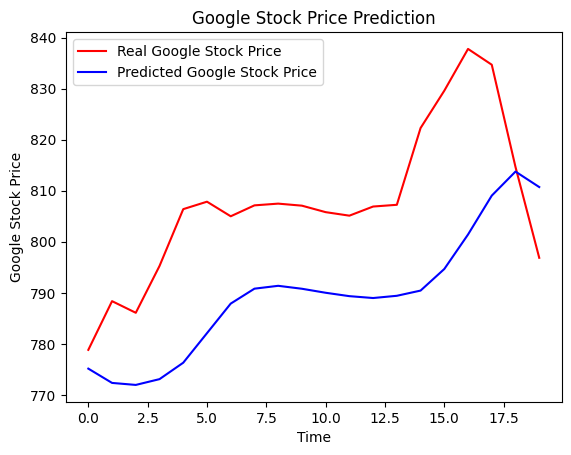

In [61]:
real_stock_price = dataset_test.iloc[:, 1:2].values

plt.plot(real_stock_price, color = 'red', label = 'Real Google Stock Price')
plt.plot(predicted_stock_price, color = 'blue', label = 'Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()